# Simple EDA And Data Cleaning

## 1. Load Raw Data


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH = '../data/all_house_prices.csv'
OUTPUT_DIR = '../data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(RAW_PATH, low_memory=False)
df.head()


,Title,Description,Amount,Price_per_sqft,City,Carpet Area,Status,Floor,Transaction,Furnishing,Facing,Overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,3 BHK Ready to Occupy Flat for sale in Brigad...,Multistorey apartment is available for sale. I...,₹92 Lac,₹8821 per sqft,Bangalore,628 sqft,Ready to Move,6 out of 15,Resale,Unfurnished,NaN,NaN,NaN,2,1,NaN,NaN,NaN,NaN,NaN
1,2 BHK Ready to Occupy Flat for sale in Purva ...,This spacious 2 BHK apartment can be found for...,₹2.05 Cr,₹16066 per sqft,Bangalore,NaN,Ready to Move,22 out of 33,Resale,Unfurnished,NaN,NaN,NaN,2,1,NaN,NaN,1276 sqft,NaN,NaN
2,3 BHK Ready to Occupy Flat for sale Uttarahal...,"15th Floor, 1367sqft, 2.5 bhk apartment, city ...",₹2.20 Cr,₹16094 per sqft,Bangalore,985 sqft,Ready to Move,15 out of 18,Resale,Semi-Furnished,NaN,NaN,NaN,2,1,NaN,Freehold,NaN,NaN,NaN
3,4 BHK Ready to Occupy Flat for sale in Purva ...,An Elegant 4 BHK flat located in New Internati...,₹2.65 Cr,₹12482 per sqft,Bangalore,NaN,Ready to Move,8 out of 14,Resale,Unfurnished,NaN,NaN,NaN,4,2,NaN,Freehold,2123 sqft,NaN,NaN
4,2 BHK Ready to Occupy Flat for sale Electroni...,1100 Sq.ft 2BHK with Vitrified Palace like Til...,₹42 Lac,₹4200 per sqft,Bangalore,NaN,Ready to Move,2 out of 3,Resale,Semi-Furnished,NaN,NaN,NaN,2,3,NaN,Freehold,1000 sqft,NaN,NaN


## 2. Quick Data Info


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192535 entries, 0 to 192534
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Title           192535 non-null  object 
 1   Description     192535 non-null  object 
 2   Amount          192535 non-null  object 
 3   Price_per_sqft  180714 non-null  object 
 4   City            192535 non-null  object 
 5   Carpet Area     134110 non-null  object 
 6   Status          192423 non-null  object 
 7   Floor           189807 non-null  object 
 8   Transaction     191987 non-null  object 
 9   Furnishing      189600 non-null  object 
 10  Facing          0 non-null       float64
 11  Overlooking     0 non-null       float64
 12  Society         94186 non-null   object 
 13  Bathroom        191744 non-null  object 
 14  Balcony         132440 non-null  object 
 15  Car Parking     78830 non-null   object 
 16  Ownership       127401 non-null  object 
 17  Super Area

## 3. Dataset Overview


In [4]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print(df.columns.tolist())

Rows: 192535
Columns: 20
['Title', 'Description', 'Amount', 'Price_per_sqft', 'City', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'Facing', 'Overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']


## 4. Missing Values


In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Facing            192535
Overlooking       192535
Dimensions        192535
Plot Area         192535
Super Area        134159
Car Parking       113705
Society            98349
Ownership          65134
Balcony            60095
Carpet Area        58425
Price_per_sqft     11821
Furnishing          2935
Floor               2728
Bathroom             791
Transaction          548
Status               112
dtype: int64

## 5. Duplicate Rows


In [6]:
print('Exact duplicate rows:', int(df.duplicated().sum()))

Exact duplicate rows: 149034


## 6. City Wise Property Count


City
Mumbai         30900
Pune           29310
Bangalore      25530
New Delhi      20040
Kolkata        18390
Hyderabad      15960
Gurgaon        13320
Noida           7560
Chennai         7020
Navi Mumbai     6480
Name: count, dtype: int64


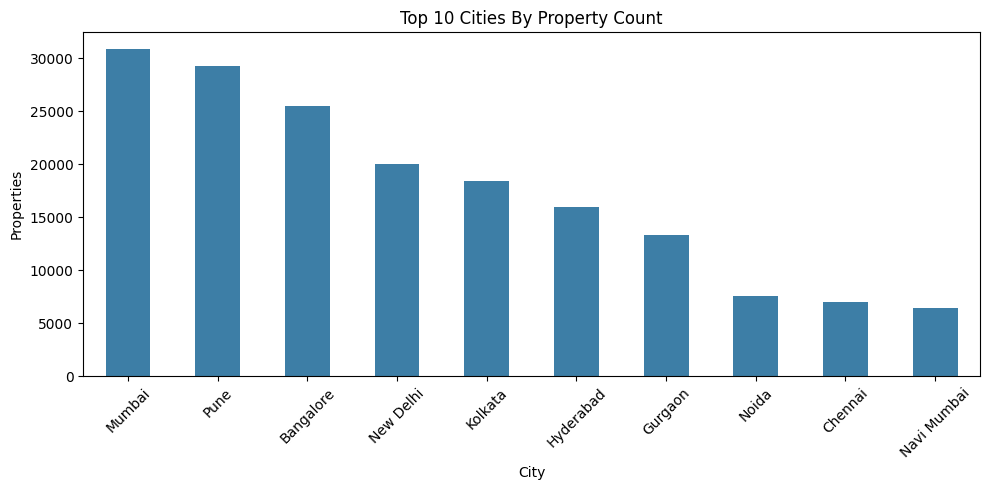

In [7]:
city_counts = df['City'].value_counts()
print(city_counts.head(10))

city_counts.head(10).plot(kind='bar', figsize=(10, 5), color='#3d7ea6')
plt.title('Top 10 Cities By Property Count')
plt.xlabel('City')
plt.ylabel('Properties')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Price Distribution


count    1.896670e+05
mean     5.770767e+03
std      2.411008e+06
min      1.000000e+00
25%      6.500000e+01
50%      1.250000e+02
75%      2.550000e+02
max      1.050000e+09
Name: 0, dtype: float64


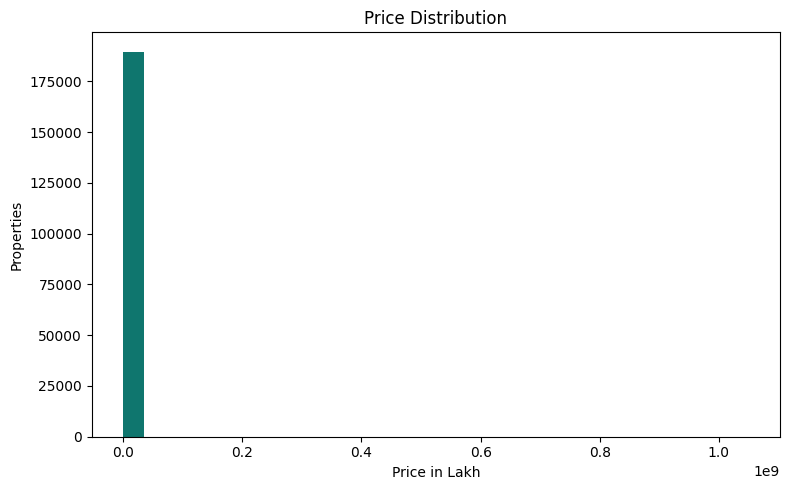

In [8]:
price_text = df['Amount'].fillna('').astype(str).str.lower().str.replace(',', '', regex=False)
price_value = price_text.str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)
price_lakh = price_value.where(price_text.str.contains('lac|lakh', na=False), np.nan)
price_lakh = price_lakh.where(~price_text.str.contains('cr|crore', na=False), price_value * 100)
print(price_lakh.describe())

price_lakh.dropna().plot(kind='hist', bins=30, figsize=(8, 5), color='#0f766e')
plt.title('Price Distribution')
plt.xlabel('Price in Lakh')
plt.ylabel('Properties')
plt.tight_layout()
plt.show()


## 8. BHK Count


In [9]:
bhk = df['Title'].astype(str).str.extract(r'(\d+)\s*BHK', expand=False)
bhk.value_counts().head(10)

Title
2     78188
3     67277
1     22011
4     16460
5      5619
6       593
10       35
8        15
7        11
9         5
Name: count, dtype: int64

## 9. Remove Exact Duplicates


In [10]:
print('Rows before:', len(df))
df = df.drop_duplicates().copy()
print('Rows after:', len(df))

Rows before: 192535
Rows after: 43501


## 10. Check Nulls After Deduplication


In [11]:
print('DataFrame info after removing exact duplicates:')
df.info()
print('\nNull values after removing exact duplicates:')
print(df.isna().sum())

DataFrame info after removing exact duplicates:
<class 'pandas.core.frame.DataFrame'>
Index: 43501 entries, 0 to 192533
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Title           43501 non-null  object 
 1   Description     43501 non-null  object 
 2   Amount          43501 non-null  object 
 3   Price_per_sqft  40963 non-null  object 
 4   City            43501 non-null  object 
 5   Carpet Area     26947 non-null  object 
 6   Status          43389 non-null  object 
 7   Floor           41975 non-null  object 
 8   Transaction     43463 non-null  object 
 9   Furnishing      42936 non-null  object 
 10  Facing          0 non-null      float64
 11  Overlooking     0 non-null      float64
 12  Society         19465 non-null  object 
 13  Bathroom        43336 non-null  object 
 14  Balcony         29414 non-null  object 
 15  Car Parking     17012 non-null  object 
 16  Ownership       26509 non-null  

## 11. Create Clean Features


In [12]:
clean_df = pd.DataFrame()

clean_df['city'] = df['City'].fillna('').astype(str).str.strip()
clean_df['title'] = df['Title'].fillna('').astype(str).str.strip()
clean_df['description'] = df['Description'].fillna('').astype(str).str.strip()
clean_df['description'] = clean_df['description'].str.replace('???', 'Rs ', regex=False)
clean_df['description'] = clean_df['description'].str.replace('?', 'Rs ', regex=False)
clean_df['status'] = df['Status'].fillna('Unknown').astype(str).str.strip()
clean_df['price_lakh'] = price_lakh

carpet_area = df['Carpet Area'].fillna('').astype(str).str.lower().str.replace(',', '', regex=False)
carpet_value = carpet_area.str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)
super_area = df['Super Area'].fillna('').astype(str).str.lower().str.replace(',', '', regex=False)
super_value = super_area.str.extract(r'(\d+(?:\.\d+)?)')[0].astype(float)

# 1 sqr yard = 9 sq ft
clean_df['area_sqft'] = carpet_value.where(
    ~carpet_area.str.contains('sqyrd|sq yard|sq. yard', na=False),
    carpet_value * 9,
)
clean_df['area_sqft'] = clean_df['area_sqft'].fillna(super_value)
clean_df['bhk'] = df['Title'].fillna('').astype(str).str.extract(r'(\d+)\s*BHK', expand=False).astype(float)
clean_df['bathrooms'] = df['Bathroom'].fillna('').astype(str).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
clean_df['balconies'] = df['Balcony'].fillna('').astype(str).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float).fillna(1)
parking_text = df['Car Parking'].fillna('').astype(str).str.strip().str.lower()
clean_df['parking_count'] = parking_text.ne('').astype(int)

floor_text = df['Floor'].fillna('').astype(str).str.lower()
clean_df['current_floor'] = floor_text.str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
clean_df.loc[floor_text.str.contains('ground', na=False), 'current_floor'] = 0
clean_df['current_floor'] = clean_df['current_floor'].fillna(1)
clean_df['total_floors'] = floor_text.str.extract(r'(\d+)(?!.*\d)', expand=False).astype(float).fillna(1)

clean_df['property_type'] = clean_df['title'].str.extract(r'BHK\s+(.+?)\s+for', expand=False).fillna('Property')
clean_df['transaction'] = df['Transaction'].fillna('Unknown').astype(str).str.strip()
clean_df['furnishing'] = df['Furnishing'].fillna('Unknown').astype(str).str.strip()
clean_df['ownership'] = df['Ownership'].fillna('Unknown').astype(str).str.strip()

clean_df = clean_df[clean_df['transaction'].str.lower().ne('unknown')].copy()
clean_df = clean_df.drop(columns=['society'], errors='ignore')
clean_df.head()


,city,title,description,status,price_lakh,area_sqft,bhk,bathrooms,balconies,parking_count,current_floor,total_floors,property_type,transaction,furnishing,ownership
0,Bangalore,3 BHK Ready to Occupy Flat for sale in Brigad...,Multistorey apartment is available for sale. I...,Ready to Move,92.0,628.0,3.0,2.0,1.0,0,6.0,15.0,Ready to Occupy Flat,Resale,Unfurnished,Unknown
1,Bangalore,2 BHK Ready to Occupy Flat for sale in Purva ...,This spacious 2 BHK apartment can be found for...,Ready to Move,205.0,1276.0,2.0,2.0,1.0,0,22.0,33.0,Ready to Occupy Flat,Resale,Unfurnished,Unknown
2,Bangalore,3 BHK Ready to Occupy Flat for sale Uttarahal...,"15th Floor, 1367sqft, 2.5 bhk apartment, city ...",Ready to Move,220.0,985.0,3.0,2.0,1.0,0,15.0,18.0,Ready to Occupy Flat,Resale,Semi-Furnished,Freehold
3,Bangalore,4 BHK Ready to Occupy Flat for sale in Purva ...,An Elegant 4 BHK flat located in New Internati...,Ready to Move,265.0,2123.0,4.0,4.0,2.0,0,8.0,14.0,Ready to Occupy Flat,Resale,Unfurnished,Freehold
4,Bangalore,2 BHK Ready to Occupy Flat for sale Electroni...,1100 Sq.ft 2BHK with Vitrified Palace like Til...,Ready to Move,42.0,1000.0,2.0,2.0,3.0,0,2.0,3.0,Ready to Occupy Flat,Resale,Semi-Furnished,Freehold


## 12. Keep Valid Rows


In [13]:
clean_df = clean_df.dropna(
    subset=['city', 'price_lakh', 'area_sqft', 'bhk', 'bathrooms', 'furnishing']
)
clean_df = clean_df[
    ~clean_df['furnishing'].str.lower().isin(['unknown', 'none'])
]
clean_df = clean_df[
    clean_df['transaction'].str.lower() != 'other'
]
clean_df = clean_df[
    (clean_df['price_lakh'] > 0) & (clean_df['area_sqft'] > 0)
]

print('Clean rows:', len(clean_df))
clean_df.head()

Clean rows: 42016


,city,title,description,status,price_lakh,area_sqft,bhk,bathrooms,balconies,parking_count,current_floor,total_floors,property_type,transaction,furnishing,ownership
0,Bangalore,3 BHK Ready to Occupy Flat for sale in Brigad...,Multistorey apartment is available for sale. I...,Ready to Move,92.0,628.0,3.0,2.0,1.0,0,6.0,15.0,Ready to Occupy Flat,Resale,Unfurnished,Unknown
1,Bangalore,2 BHK Ready to Occupy Flat for sale in Purva ...,This spacious 2 BHK apartment can be found for...,Ready to Move,205.0,1276.0,2.0,2.0,1.0,0,22.0,33.0,Ready to Occupy Flat,Resale,Unfurnished,Unknown
2,Bangalore,3 BHK Ready to Occupy Flat for sale Uttarahal...,"15th Floor, 1367sqft, 2.5 bhk apartment, city ...",Ready to Move,220.0,985.0,3.0,2.0,1.0,0,15.0,18.0,Ready to Occupy Flat,Resale,Semi-Furnished,Freehold
3,Bangalore,4 BHK Ready to Occupy Flat for sale in Purva ...,An Elegant 4 BHK flat located in New Internati...,Ready to Move,265.0,2123.0,4.0,4.0,2.0,0,8.0,14.0,Ready to Occupy Flat,Resale,Unfurnished,Freehold
4,Bangalore,2 BHK Ready to Occupy Flat for sale Electroni...,1100 Sq.ft 2BHK with Vitrified Palace like Til...,Ready to Move,42.0,1000.0,2.0,2.0,3.0,0,2.0,3.0,Ready to Occupy Flat,Resale,Semi-Furnished,Freehold


## 13. Save Clean Dataset


In [14]:
CSV_PATH = os.path.join(OUTPUT_DIR, 'simple_house_properties_clean.csv')

clean_df.to_csv(CSV_PATH, index=False)

print('Saved:', CSV_PATH)
print('Rows:', len(clean_df))


Saved: ../data/processed\simple_house_properties_clean.csv
Rows: 42016
